<a href="https://colab.research.google.com/github/idawalier88-tech/Referat-BewertungDerFeatureImportance/blob/main/RandomForestModell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Bibliotheken importieren

First, we'll import all the necessary libraries for data manipulation, model building, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

import shap

### 2. AI4I 2020 Predictive Maintenance Dataset laden

Next, we'll download the dataset, load it into a pandas DataFrame, define our target variable `y`, and prepare our features `X` by dropping the specified columns.

In [ ]:
import pandas as pd

# Load the dataset
url = "https://raw.githubusercontent.com/youssef-marzouk/predictive_maintenance/master/ai4i2020.csv"
try:
    df = pd.read_csv(url)
except Exception:
    url_alt = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
    df = pd.read_csv(url_alt)

# Create the target variable
y = df["Machine failure"]

# Columns representing concrete failure modes (causes) to be removed
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# 1. Drop identifier columns and failure modes
X_raw = df.drop(columns=["Product ID", "UDI", "Machine failure"] + failure_modes)

# 2. One-Hot-Encode the 'Type' column (M, L, H) into numeric features
X = pd.get_dummies(X_raw, columns=["Type"], drop_first=False, dtype=int)

# Get updated feature names
feature_names = X.columns.tolist()

print("Dataset loaded successfully (with One-Hot Encoded 'Type' categories and no leakage). First 5 rows of X:")
display(X.head())
print(f"Active features: {feature_names}")

Dataset loaded successfully (with One-Hot Encoded 'Type' categories and no leakage). First 5 rows of X:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


Active features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']


### 3. Daten aufteilen

We will now split our dataset into training and testing sets using `train_test_split` with a test size of 30% and a `random_state` for reproducibility.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8000, 8)
X_test shape: (2000, 8)
y_train shape: (8000,)
y_test shape: (2000,)


### 4. Random Forest trainieren

Now, we'll train a `RandomForestClassifier` with the specified parameters.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 5. Modell bewerten

After training, we'll evaluate the model's performance using `accuracy_score` and `classification_report`. This dataset is imbalanced, so the `classification_report` will be crucial to see performance on the minority class.

In [ ]:
y_pred = rf_model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9825

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.88      0.49      0.63        61

    accuracy                           0.98      2000
   macro avg       0.93      0.74      0.81      2000
weighted avg       0.98      0.98      0.98      2000



### 6. Hyperparameter-Optimierung mit GridSearchCV

To find the best performing model, we'll perform a hyperparameter optimization using `GridSearchCV` with the specified parameter grid and cross-validation settings.

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters found: {'max_depth': 15, 'n_estimators': 250}
Best cross-validation accuracy: 0.982375

Test accuracy with best model: 0.9850

Classification Report for best model:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.90      0.57      0.70        61

    accuracy                           0.98      2000
   macro avg       0.94      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



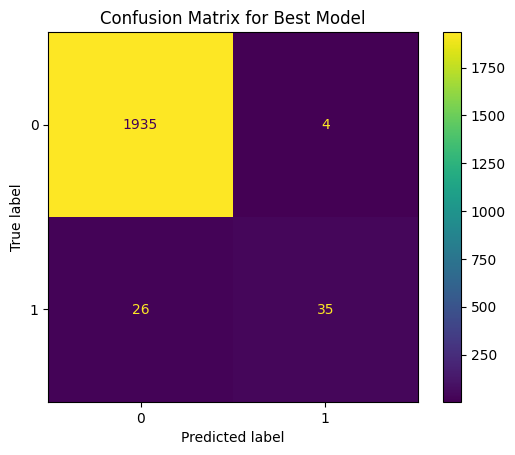

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

param_grid = {
    'n_estimators': [150, 200, 250, 300, 400],
    'max_depth': [15, 20, 25, None]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

print("\nBest parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

y_pred_best = best_rf_model.predict(X_test)

print(f"\nTest accuracy with best model: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report for best model:\n")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best, labels=best_rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf_model.classes_)
disp.plot()
plt.title('Confusion Matrix for Best Model')
plt.show()

### 8. Feature Importance berechnen

Finally, we'll calculate and visualize feature importances using three different methods: Mean Decrease in Impurity (MDI), Permutation Importance, and SHAP values.

#### 8.1 Mean Decrease in Impurity (MDI)

This method measures how much the impurity decreases on average for each feature across all trees in the forest. We'll visualize it with a bar chart.

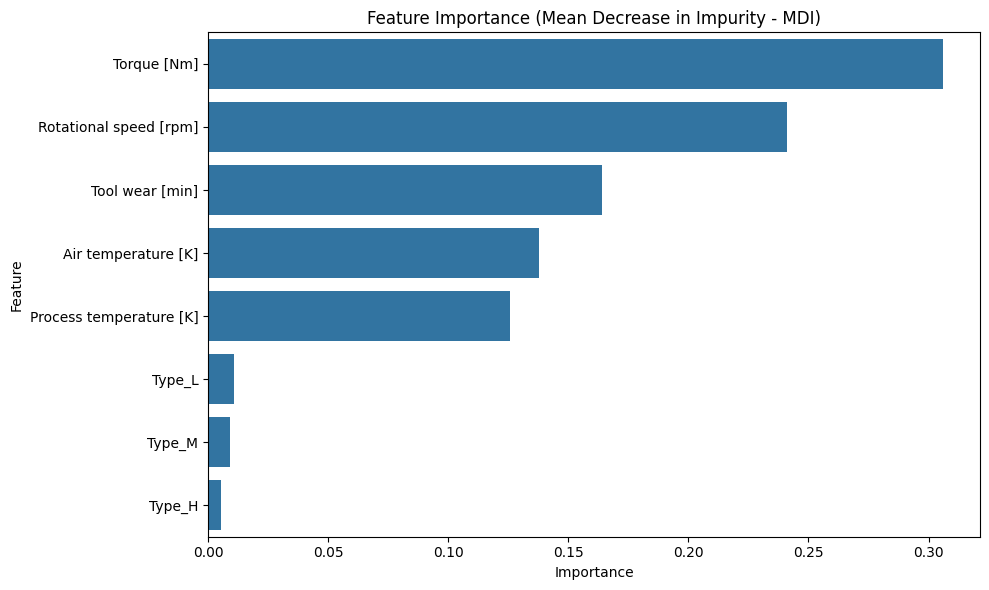

In [ ]:
mdi_importance = best_rf_model.feature_importances_
mdi_df = pd.DataFrame({'Feature': feature_names, 'Importance': mdi_importance})
mdi_df = mdi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=mdi_df)
plt.title('Feature Importance (Mean Decrease in Impurity - MDI)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### 8.2 Permutation Importance

Permutation importance measures the decrease in a model's score when a single feature is randomly shuffled. This breaks the relationship between the feature and the target, thus the drop in the model score is indicative of how much the model depends on that feature. We will calculate it on the test set.

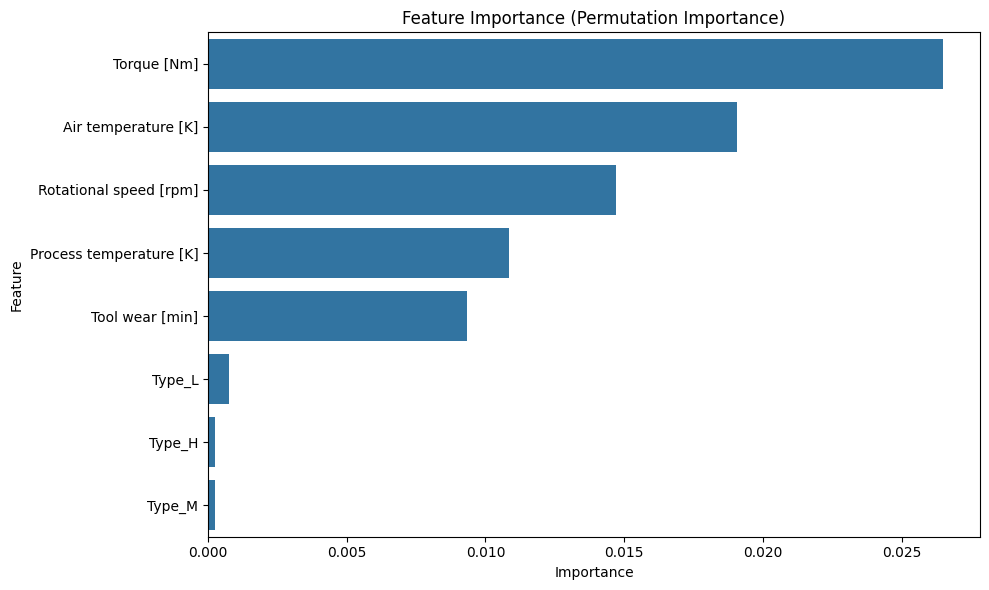

In [ ]:
perm_importance_results = permutation_importance(
    best_rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_mean = perm_importance_results.importances_mean
perm_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm_importance_mean})
perm_df = perm_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=perm_df)
plt.title('Feature Importance (Permutation Importance)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### 8.3 SHAP (SHapley Additive exPlanations)

SHAP values explain the prediction of an instance by computing the contribution of each feature to the prediction. We will generate a Summary Plot and a Dependence Plot for the most important feature based on SHAP values.

In [ ]:
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated.")

SHAP values calculated.


##### SHAP Summary Plot

The summary plot combines feature importance with feature effects. Each point on the summary plot is a Shapley value for a feature and an instance. The position on the y-axis is determined by the feature, and on the x-axis by the Shapley value. Color represents the feature's value (red for high, blue for low).

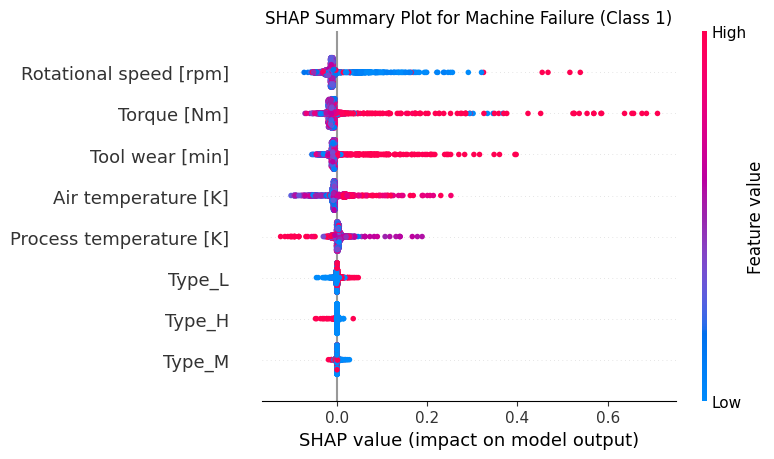

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot for Machine Failure (Class 1)')
plt.tight_layout()
plt.show()

##### SHAP Dependence Plot

The dependence plot shows the effect of a single feature on the predictions. It displays the Shapley value for a feature versus the actual value of that feature. We'll plot this for the most important feature (e.g., based on MDI or permutation importance).

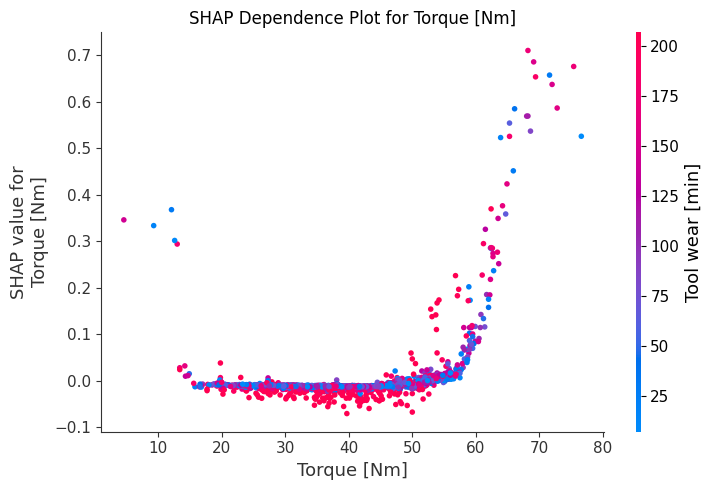

In [ ]:
# Identify the most important feature from MDI for the dependence plot
most_important_feature = mdi_df.iloc[0]['Feature']

# Get the index of the most important feature
most_important_feature_idx = feature_names.index(most_important_feature)

shap.dependence_plot(
    most_important_feature_idx,
    shap_values[:, :, 1],
    X_test,
    feature_names=feature_names,
    display_features=X_test,
    show=False
)
plt.title(f'SHAP Dependence Plot for {most_important_feature}')
plt.tight_layout()
plt.show()